# Week 5 - Wed Lab (09/30/26) 

This code accompanies activities for the 09/30/26 lab.

**Table of Contents**

1. [Plicker Questions Code](#sec1)
2. [Cosine Similarity Whiteboard Activity - Your Task](#sec2)
3. [Wikipedia country-specific data](#sec3)

<a id="sec1"></a>
## 1. Plicker Questions Code

This code relates to the Question 13 on the Plicker set of questions for today. We will run the code line by line to see what is going on.

In [1]:
from datetime import datetime, timedelta

**Create a new datetime object**

In [2]:
date1 = datetime(2023, 5, 1)
type(date1)

datetime.datetime

**Create a new timedelta object**

In [3]:
delta = timedelta(days=10)
type(delta)

datetime.timedelta

In [4]:
print(delta)

10 days, 0:00:00


**Adding the two objects**

In [5]:
date2 = date1 + delta
print(date2)

2023-05-11 00:00:00


**Why is this possible?**

Let's show all methods / properties of the object:

In [6]:
dir(date1)

['__add__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rsub__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 'astimezone',
 'combine',
 'ctime',
 'date',
 'day',
 'dst',
 'fold',
 'fromisocalendar',
 'fromisoformat',
 'fromordinal',
 'fromtimestamp',
 'hour',
 'isocalendar',
 'isoformat',
 'isoweekday',
 'max',
 'microsecond',
 'min',
 'minute',
 'month',
 'now',
 'replace',
 'resolution',
 'second',
 'strftime',
 'strptime',
 'time',
 'timestamp',
 'timetuple',
 'timetz',
 'today',
 'toordinal',
 'tzinfo',
 'tzname',
 'utcfromtimestamp',
 'utcnow',
 'utcoffset',
 'utctimetuple',
 'weekday',
 'year']

Let's look up the docstring of the method `__add__`, which is what is called when we use the + operator:

In [7]:
help(date1.__add__)

Help on method-wrapper:

__add__ = <method-wrapper '__add__' of datetime.datetime object>
    Return self+value.



**Conclusion:** There is a class method that will accept any value type and then act accordingly to figure out how to add that value to the date, if possible.

<a id="sec2"></a>
## 2. Cosine Similarity Whiteboard Activity

This activity was completed by hand, here is how to do it via Python code.

### Inputs for the problem

In [8]:
documents = [
    "Max likes Sam.",    # D1
    "Sam likes Max.",    # D2
    "Max and Sam.",      # D3
    "Winter likes fall." # D4
]

query = "Sam likes winter"

### Step 1: Create vocabulary of all terms

First I will concatenate all strings into one.

In [9]:
allText = " ".join(documents + [query])
print(allText)

Max likes Sam. Sam likes Max. Max and Sam. Winter likes fall. Sam likes winter


I don't want to have punctuation. There are several ways to do that. Let's see some:

#### Method 1: Iterate over the string, leave out punctuations

In [10]:
import string
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [11]:
allText_noPunct = "".join([ch for ch in allText if not ch in string.punctuation])
print(allText_noPunct)

Max likes Sam Sam likes Max Max and Sam Winter likes fall Sam likes winter


### Method 2: Use built-in methods

Pythyn's built-in `str` class has many useful methods for translating a set of characters to another one. Let's see the method in action:

In [12]:
allText.translate(str.maketrans("", "", string.punctuation))

'Max likes Sam Sam likes Max Max and Sam Winter likes fall Sam likes winter'

What's going on?

In [13]:
print(str.maketrans("", "", string.punctuation))

{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}


We can see that all ASCII Characters from 0-32 and from 65 to 90 are missing, because those characters will be deleted.

Here is what is happening:

```
str.maketrans(from_str, to_str, delete_chars)
#              ^          ^        ^
#           1st arg    2nd arg  3rd arg
```

* 1st argument (""): The characters you want to replace. (Empty string = replace nothing)

* 2nd argument (""): The characters to replace them with. (Empty string = no replacement mapping)

* 3rd argument (string.punctuation): The characters you want to delete entirely.

### Our vocabulary

Here is a Python one-liner that takes our variable `allText_noPunct` and find the unique words in it.

In [14]:
words = set(allText_noPunct.lower().split())
words

{'and', 'fall', 'likes', 'max', 'sam', 'winter'}

In [15]:
voc = sorted(words)
voc

['and', 'fall', 'likes', 'max', 'sam', 'winter']

### YOUR TURN

Write code to implement the other steps of the process shown in Slide 7.

**Show your process before writing any functions.**

**Use markdown to label the three remaining steps.**

The remaining steps are as follows:

2.  Represent each document and the query in the vector space created by these terms

3. Calculate the cosine similarity between the query and each document

4. Rank the results based on the cosine similarity

### Step 2:

In [16]:
# First, I want to look at the vocab again.
print(voc)

# For each document, count how many times each word in the vocabulary appears, then add it to the table.
vectors = []

for doc in documents + [query]:
    doc_noPunct = doc.translate(str.maketrans("", "", string.punctuation))
    doc_words = doc_noPunct.lower().split()
    
    vector = []
    
    for word in voc:
        vector.append(doc_words.count(word))
    
    vectors.append(vector)

vectors

['and', 'fall', 'likes', 'max', 'sam', 'winter']


[[0, 0, 1, 1, 1, 0],
 [0, 0, 1, 1, 1, 0],
 [1, 0, 0, 1, 1, 0],
 [0, 1, 1, 0, 0, 1],
 [0, 0, 1, 0, 1, 1]]

In [17]:
# The first four vectors correspond to D1-D4.
# The fifth vector corresponds to the query.
print("D1:", vectors[0])
print("D2:", vectors[1])
print("D3:", vectors[2])
print("D4:", vectors[3])
print("Query:", vectors[4])

D1: [0, 0, 1, 1, 1, 0]
D2: [0, 0, 1, 1, 1, 0]
D3: [1, 0, 0, 1, 1, 0]
D4: [0, 1, 1, 0, 0, 1]
Query: [0, 0, 1, 0, 1, 1]


### Step 3:

In [18]:
import numpy as np

# I'm showing it here, step by step. I have a more detailed layout in Week 4.
# Again, there's lots of ways to do this, but since I demonstrated that I can do it without complicated numpy functions in Week 4,
# I'm doing it this way this time.

doc_vector = np.array(vectors[0])
query_vector = np.array(vectors[-1])

# Dot product
dot_product = np.dot(doc_vector, query_vector)

# Magnitudes of the two vectors
magnitude_doc = np.linalg.norm(doc_vector)
magnitude_query = np.linalg.norm(query_vector)

# Cosine similarity
similarity = dot_product / (magnitude_doc * magnitude_query)

print("D1 dot query:", dot_product)
print("D1 magnitude:", magnitude_doc)
print("Query magnitude:", magnitude_query)
print("Cosine similarity:", similarity)

# Now that I have shown the calculation step by step,
# I can put the calculation into a function so that
# I can repeat it for every document.

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    magnitude1 = np.linalg.norm(vec1)
    magnitude2 = np.linalg.norm(vec2)
    
    return dot_product / (magnitude1 * magnitude2)

query_vector = vectors[-1]

similarities = []

for i in range(len(documents)):
    similarity = cosine_similarity(vectors[i], query_vector)
    similarities.append(similarity)

for i, similarity in enumerate(similarities):
    print(f"D{i + 1}: {similarity:.4f}")

D1 dot query: 2
D1 magnitude: 1.7320508075688772
Query magnitude: 1.7320508075688772
Cosine similarity: 0.6666666666666667
D1: 0.6667
D2: 0.6667
D3: 0.3333
D4: 0.6667


### Step 4: Ranking

In [19]:
ranked_indices = np.argsort(similarities)[::-1] # I'm lazy, but numpy has lots of helpful functions

for rank, i in enumerate(ranked_indices, start=1):
    print(
        f"{rank}. D{i + 1}: "
        f"{similarities[i]:.4f} - "
        f"{documents[i]}"
    )
    
most_similar_index = ranked_indices[0]

print("\nMost similar document:", f"D{most_similar_index + 1}")
print("Cosine similarity:", similarities[most_similar_index])
print("Document:", documents[most_similar_index])

1. D4: 0.6667 - Winter likes fall.
2. D2: 0.6667 - Sam likes Max.
3. D1: 0.6667 - Max likes Sam.
4. D3: 0.3333 - Max and Sam.

Most similar document: D4
Cosine similarity: 0.6666666666666667
Document: Winter likes fall.


<a id="sec3"></a>
## 3. Wikipedia Country-Specific Data

If we know the URL of a date, for example:

```
https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-29.tsv
```

we can use pandas to read the content of the file into a dataframe. 

In [20]:
# import pandas as pd

# url = "https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-29.tsv"

# df = pd.read_csv(url, sep='\t')

# df.head()

Why did this happen? Wikimedia didn't like that we didn't identify ourselves. This is why we need to first get data with requests, then read it from pandas.

In [21]:
import pandas as pd
import requests, io

url = "https://analytics.wikimedia.org/published/datasets/country_project_page/2026-09-29.tsv"

headers = {'User-Agent': 'MyDataAnalysisScript/1.0 (contact: wendywellesley@gmail.com)'}
response = requests.get(url, headers=headers)

df = pd.read_csv(io.StringIO(response.text), sep='\t')
df.head()

,Algeria,DZ,ar.wikipedia,3947,Ø°ÙØ§Ø¡_Ø§ØµØ·ÙØ§Ø¹Ù,Q11660,122
0,Argentina,AR,es.wikipedia,3094323,Juana_Viale,Q9016209,115
1,Argentina,AR,es.wikipedia,327209,JosÃ©_Mourinho,Q79983,114
2,Argentina,AR,es.wikipedia,4449701,Copa_Libertadores,Q184795,386
3,Argentina,AR,es.wikipedia,47340,Thomas_Sankara,Q202155,119
4,Argentina,AR,es.wikipedia,5640452,Michael_Jackson,Q2831,177


The dataframe doesn't have column name. 

**Your task:** Read the README file to find out the column names and add them to the dataframe.


In [22]:
### Add column names from the README - https://analytics.wikimedia.org/published/datasets/country_project_page/00_README.html
column_names = [
    "country",
    "country_code", # I didn't see this in the readme, but it's in the tsv, so I'm a bit confused?
    "project",
    "page_id",
    "page_title",
    "item_id",
    "gbc",
]

df.columns = column_names

df.head()

,country,country_code,project,page_id,page_title,item_id,gbc
0,Argentina,AR,es.wikipedia,3094323,Juana_Viale,Q9016209,115
1,Argentina,AR,es.wikipedia,327209,JosÃ©_Mourinho,Q79983,114
2,Argentina,AR,es.wikipedia,4449701,Copa_Libertadores,Q184795,386
3,Argentina,AR,es.wikipedia,47340,Thomas_Sankara,Q202155,119
4,Argentina,AR,es.wikipedia,5640452,Michael_Jackson,Q2831,177


### Identify the K-dramas

Since we're asking the question "How popular were the top most recent Kdramas around the world in the month of September 2026?", I took the example advanced search "https://mydramalist.com/search?adv=titles&ty=68&fm=7&co=3&re=2026,2026&ep=1,16&rt=6,10&so=newest&or=desc" and broke it down:

 - adv=titles: Performs an Advanced Title Search.

 - ty=68: Type filter set to South Korean Dramas (K-Dramas / television shows).

 - fm=7: Format or genre filter (typically corresponds to TV Series / Dramas).

 - co=3: Country of origin set to South Korea.

 - re=2026,2026: Release year range restricted strictly to 2026.

 - ep=1,16: Episode count range filtered between 1 and 16 episodes (the typical length for standard mini-series/dramas).

 - rt=6,10: User rating range filtered between 6.0 and 10.0 (filtering out poorly rated or unrated titles).

 - o=newest & or=desc: Sorted by the newest release date in descending order.

 Setting the rating to between 6 and 10 returned many titles, so after a couple of trials, I adjusted it to between 8-10, which returned 35 results. Then, I manually selected the top 10.

In [23]:
shows = pd.DataFrame({
    "mdl_title": [
        "Teach You a Lesson", # 9.0, rank 64
        "Four Hands, Two Sonatas", # 8.7, rank 204
        "Bloodhounds Season 2", # 8.7, rank 299
        "Agent Kim Reactivated", # 8.6, rank 337
        "Yumi's Cells Season 3", # 8.6, rank 371
        "We Are All Trying Here", # 8.5, rank 528
        "A Shop for Killers Season 2", # 8.5, rank 539 (Ahhhh I hadn't realized it was out already! Must watch immediately)
        "The WONDERfools", # 8.5, rank 551
        "The Legend of Kitchen Soldier", # 8.5, rank 716
        "In Your Radiant Season", # 8.4, rank 735
    ],
    
    "wikipedia_title": [
        "Teach_You_a_Lesson",
        "Four_Hands,_Two_Sonatas",
        "Bloodhounds_(TV_series)", # not-first-season
        "Agent_Kim_Reactivated",
        "Yumi's_Cells", # not-first-season, is also a webtoon
        "We_Are_All_Trying_Here",
        "A_Shop_for_Killers", # not-first-season
        "The_Wonderfools",
        "The_Legend_of_Kitchen_Soldier",
        "In_Your_Radiant_Season",
    ],
    
    "mdl_rating": [9.0, 8.7, 8.7, 8.6, 8.6, 8.5, 8.5, 8.5, 8.5, 8.4]
})

shows

,mdl_title,wikipedia_title,mdl_rating
0,Teach You a Lesson,Teach_You_a_Lesson,9.0
1,"Four Hands, Two Sonatas","Four_Hands,_Two_Sonatas",8.7
2,Bloodhounds Season 2,Bloodhounds_(TV_series),8.7
3,Agent Kim Reactivated,Agent_Kim_Reactivated,8.6
4,Yumi's Cells Season 3,Yumi's_Cells,8.6
5,We Are All Trying Here,We_Are_All_Trying_Here,8.5
6,A Shop for Killers Season 2,A_Shop_for_Killers,8.5
7,The WONDERfools,The_Wonderfools,8.5
8,The Legend of Kitchen Soldier,The_Legend_of_Kitchen_Soldier,8.5
9,In Your Radiant Season,In_Your_Radiant_Season,8.4


### Download the Wikipedia data

There should be 30 total days in September, and I need to get the data for each one.

In [24]:
dates = pd.date_range(
    start="2026-09-01",
    end="2026-09-30",
    freq="D"
)

dates

DatetimeIndex(['2026-09-01', '2026-09-02', '2026-09-03', '2026-09-04',
               '2026-09-05', '2026-09-06', '2026-09-07', '2026-09-08',
               '2026-09-09', '2026-09-10', '2026-09-11', '2026-09-12',
               '2026-09-13', '2026-09-14', '2026-09-15', '2026-09-16',
               '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-20',
               '2026-09-21', '2026-09-22', '2026-09-23', '2026-09-24',
               '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-28',
               '2026-09-29', '2026-09-30'],
              dtype='datetime64[ns]', freq='D')

In [25]:
all_selected_data = []

for date in dates:
    
    date_string = date.strftime("%Y-%m-%d")
    
    url = (
        "https://analytics.wikimedia.org/published/datasets/"
        f"country_project_page/{date_string}.tsv"
    )
    
    print("Downloading:", date_string)
    
    response = requests.get(url, headers=headers)
    
    daily_df = pd.read_csv(
        io.StringIO(response.text),
        sep="\t",
        header=None
    )
    
    daily_df.columns = column_names
    
    # Keep only the rows for our 10 selected shows
    daily_selected = daily_df[
        daily_df["page_title"].isin(shows["wikipedia_title"])
    ].copy()
    
    # Keep track of which day the data came from
    daily_selected["date"] = date_string
    
    all_selected_data.append(daily_selected)

Downloading: 2026-09-01
Downloading: 2026-09-02
Downloading: 2026-09-03
Downloading: 2026-09-04
Downloading: 2026-09-05
Downloading: 2026-09-06
Downloading: 2026-09-07
Downloading: 2026-09-08
Downloading: 2026-09-09
Downloading: 2026-09-10
Downloading: 2026-09-11
Downloading: 2026-09-12
Downloading: 2026-09-13
Downloading: 2026-09-14
Downloading: 2026-09-15
Downloading: 2026-09-16
Downloading: 2026-09-17
Downloading: 2026-09-18
Downloading: 2026-09-19
Downloading: 2026-09-20
Downloading: 2026-09-21
Downloading: 2026-09-22
Downloading: 2026-09-23
Downloading: 2026-09-24
Downloading: 2026-09-25
Downloading: 2026-09-26
Downloading: 2026-09-27
Downloading: 2026-09-28
Downloading: 2026-09-29
Downloading: 2026-09-30


It took a bit, but I think it worked?

In [26]:
september_df = pd.concat(
    all_selected_data,
    ignore_index=True
)

september_df.head()

print("Number of rows:", len(september_df))
print("Number of days:", september_df["date"].nunique())
print("Number of shows:", september_df["page_title"].nunique())
print("Number of countries:", september_df["country"].nunique())

september_df["page_title"].value_counts()

Number of rows: 1199
Number of days: 30
Number of shows: 9
Number of countries: 18


page_title
Four_Hands,_Two_Sonatas          383
Agent_Kim_Reactivated            280
Teach_You_a_Lesson               240
A_Shop_for_Killers               114
The_Wonderfools                   71
Bloodhounds_(TV_series)           53
The_Legend_of_Kitchen_Soldier     28
We_Are_All_Trying_Here            22
In_Your_Radiant_Season             8
Name: count, dtype: int64

I seem to be having some issues where data for Yumi's Cells isn't showing up? I'm not sure why that's happening, but I'm going to work on the rest of the project first, and then go back and troubleshoot after.

Since the assignment asks for a csv/tsv with the rows that show pageviews for the selected shows for the entire month of September 2026, I'll do that now.

In [27]:
september_df.to_csv(
    "september_2026_kdrama_pageviews.csv",
    index=False
)

print("Saved September pageview data.")

Saved September pageview data.


### Inspecting the data

Now that we have the data, it's time to explore! I'll do the normal basic exploration first.

In [28]:
september_df.head(20)

,country,country_code,project,page_id,page_title,item_id,gbc,date
0,Malaysia,MY,en.wikipedia,75697706,A_Shop_for_Killers,Q123999260,160,2026-09-01
1,Singapore,SG,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,129,2026-09-01
2,Germany,DE,de.wikipedia,13931524,"Four_Hands,_Two_Sonatas",Q137271520,236,2026-09-01
3,United States,US,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,577,2026-09-01
4,India,IN,en.wikipedia,82034667,"Four_Hands,_Two_Sonatas",Q137271520,1082,2026-09-01
5,Australia,AU,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,106,2026-09-01
6,Malaysia,MY,en.wikipedia,82034667,"Four_Hands,_Two_Sonatas",Q137271520,427,2026-09-01
7,India,IN,en.wikipedia,78258360,The_Wonderfools,Q130748503,206,2026-09-01
8,United Kingdom,GB,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,113,2026-09-01
9,India,IN,en.wikipedia,79560156,Teach_You_a_Lesson,Q137844128,360,2026-09-01


In [29]:
countries = sorted(september_df["country"].unique())

print("Number of countries:", len(countries))
print(countries)

Number of countries: 18
['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Malaysia', 'Nigeria', 'Philippines', 'Poland', 'Romania', 'Singapore', 'Thailand', 'United Kingdom', 'United States']


In [30]:
shows_in_data = sorted(september_df["page_title"].unique())

print("Number of shows:", len(shows_in_data))
print(shows_in_data)

Number of shows: 9
['A_Shop_for_Killers', 'Agent_Kim_Reactivated', 'Bloodhounds_(TV_series)', 'Four_Hands,_Two_Sonatas', 'In_Your_Radiant_Season', 'Teach_You_a_Lesson', 'The_Legend_of_Kitchen_Soldier', 'The_Wonderfools', 'We_Are_All_Trying_Here']


### Bar Chart 1

The assignment asks for one bar chart showing the total views of these pages by country (sorted). I need to calculate the totals to figure out the top countries.

In [31]:
country_totals = (
    september_df
    .groupby("country")["gbc"]
    .sum()
    .sort_values(ascending=False)
)

country_totals.head(10)

country
United States     77634
India             48175
Indonesia         25794
Philippines       23277
Malaysia          13147
Singapore         10289
Japan             10108
Canada            10103
United Kingdom     9221
Australia          7131
Name: gbc, dtype: int64

In [32]:
print("Number of countries:", len(country_totals))

print("\nTop 10 countries:")
print(country_totals.head(10))

Number of countries: 18

Top 10 countries:
country
United States     77634
India             48175
Indonesia         25794
Philippines       23277
Malaysia          13147
Singapore         10289
Japan             10108
Canada            10103
United Kingdom     9221
Australia          7131
Name: gbc, dtype: int64


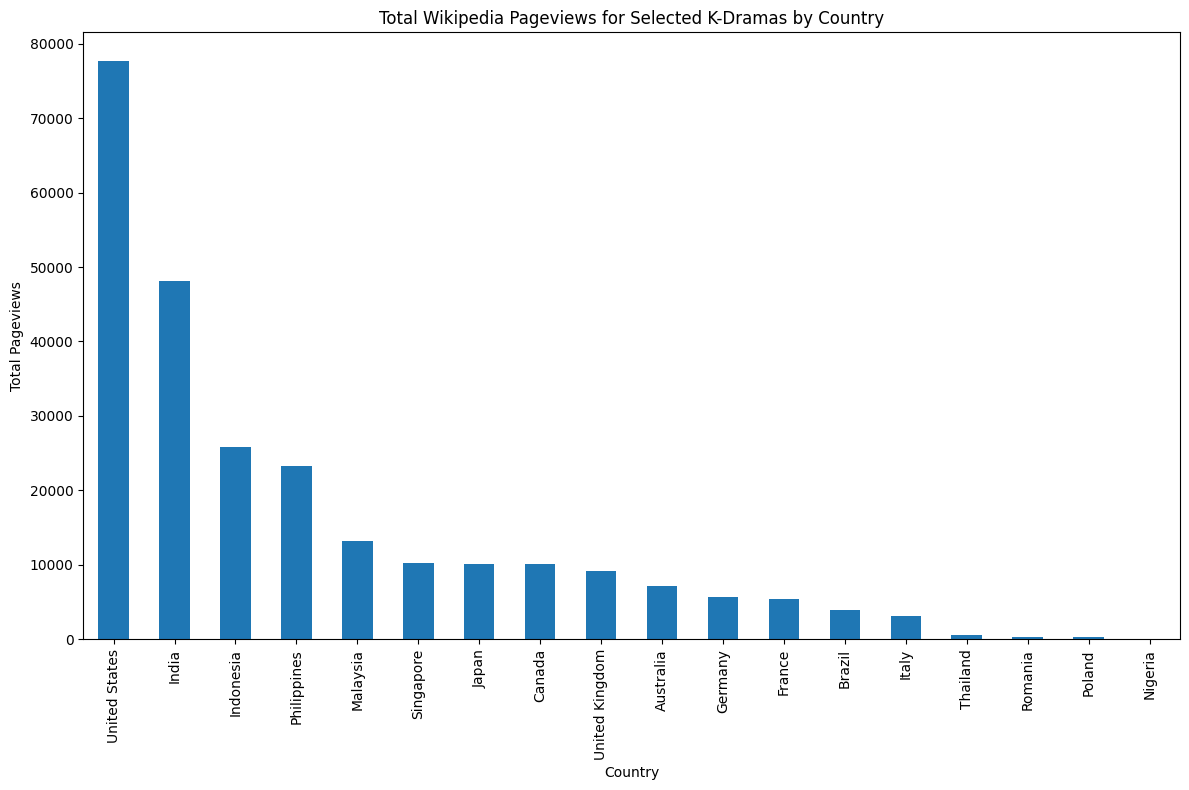

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

country_totals.plot(kind="bar")

plt.title("Total Wikipedia Pageviews for Selected K-Dramas by Country")
plt.xlabel("Country")
plt.ylabel("Total Pageviews")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Bar Chart 2

The assignment also asks for a bar chart showing the total views per show, so I'll calculate the totals and then plot.

In [34]:
show_totals = (
    september_df
    .groupby("page_title")["gbc"]
    .sum()
    .sort_values(ascending=False)
)

show_totals

page_title
Four_Hands,_Two_Sonatas          105309
Agent_Kim_Reactivated             54615
Teach_You_a_Lesson                47148
A_Shop_for_Killers                18133
The_Wonderfools                   13836
Bloodhounds_(TV_series)            8183
The_Legend_of_Kitchen_Soldier      3870
We_Are_All_Trying_Here             2492
In_Your_Radiant_Season              778
Name: gbc, dtype: int64

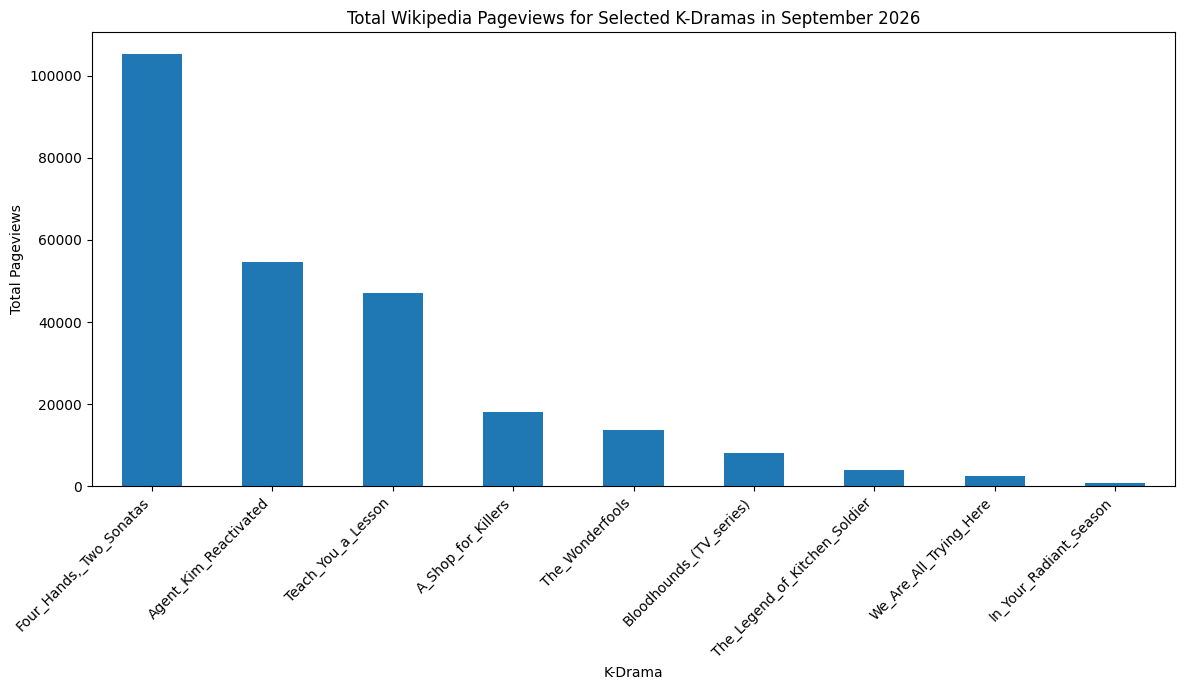

In [35]:
plt.figure(figsize=(12, 7))

show_totals.plot(kind="bar")

plt.title("Total Wikipedia Pageviews for Selected K-Dramas in September 2026")
plt.xlabel("K-Drama")
plt.ylabel("Total Pageviews")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Understanding

Based on eyeballing, it looks like Wikipedia page views do not correlate with MDL ratings? But I'm also going to make a combined table, to be sure.

In [36]:
show_results = show_totals.reset_index()

show_results.columns = [
    "wikipedia_title",
    "total_pageviews"
]

show_results

,wikipedia_title,total_pageviews
0,"Four_Hands,_Two_Sonatas",105309
1,Agent_Kim_Reactivated,54615
2,Teach_You_a_Lesson,47148
3,A_Shop_for_Killers,18133
4,The_Wonderfools,13836
5,Bloodhounds_(TV_series),8183
6,The_Legend_of_Kitchen_Soldier,3870
7,We_Are_All_Trying_Here,2492
8,In_Your_Radiant_Season,778


In [37]:
comparison = shows.merge(
    show_results,
    on="wikipedia_title",
    how="left"
)

comparison

,mdl_title,wikipedia_title,mdl_rating,total_pageviews
0,Teach You a Lesson,Teach_You_a_Lesson,9.0,47148.0
1,"Four Hands, Two Sonatas","Four_Hands,_Two_Sonatas",8.7,105309.0
2,Bloodhounds Season 2,Bloodhounds_(TV_series),8.7,8183.0
3,Agent Kim Reactivated,Agent_Kim_Reactivated,8.6,54615.0
4,Yumi's Cells Season 3,Yumi's_Cells,8.6,NaN
5,We Are All Trying Here,We_Are_All_Trying_Here,8.5,2492.0
6,A Shop for Killers Season 2,A_Shop_for_Killers,8.5,18133.0
7,The WONDERfools,The_Wonderfools,8.5,13836.0
8,The Legend of Kitchen Soldier,The_Legend_of_Kitchen_Soldier,8.5,3870.0
9,In Your Radiant Season,In_Your_Radiant_Season,8.4,778.0


In [38]:
comparison.sort_values(
    "total_pageviews",
    ascending=False
)

,mdl_title,wikipedia_title,mdl_rating,total_pageviews
1,"Four Hands, Two Sonatas","Four_Hands,_Two_Sonatas",8.7,105309.0
3,Agent Kim Reactivated,Agent_Kim_Reactivated,8.6,54615.0
0,Teach You a Lesson,Teach_You_a_Lesson,9.0,47148.0
6,A Shop for Killers Season 2,A_Shop_for_Killers,8.5,18133.0
7,The WONDERfools,The_Wonderfools,8.5,13836.0
2,Bloodhounds Season 2,Bloodhounds_(TV_series),8.7,8183.0
8,The Legend of Kitchen Soldier,The_Legend_of_Kitchen_Soldier,8.5,3870.0
5,We Are All Trying Here,We_Are_All_Trying_Here,8.5,2492.0
9,In Your Radiant Season,In_Your_Radiant_Season,8.4,778.0
4,Yumi's Cells Season 3,Yumi's_Cells,8.6,NaN


So we can clearly see that the ratings are not aligned, although they're not the worse. The second-most popular drama on MDL is the first on Wikipedia, and the least popular is also the least popular (excluding Yumi's Cells, which I will investigate). However, we also have the sixth-most popular in MDL as fourth in Wikipedia, so there are some discrepancies.

### Troubleshooting Yumi's Cells

Okay I'm not sure why Yumi's Cells isn't showing up. Previously, I had also done a search using "https://en.wikipedia.org/wiki/Yumi%27s_Cells", as that's another link that leads to the Wikipedia page, but it also returned nothing. What follows are a couple of ideas I had to see if something's happening.

In [39]:
# Find all page titles containing "Yumi" (to make sure it's not the apostrophe-vs-ascii problem)
yumi_rows = df[
    df["page_title"].str.contains("Yumi", case=False, na=False)
]

yumi_rows[["country", "page_title", "gbc"]].head(20)

,country,page_title,gbc
43455,United States,Hi_Hi_Puffy_AmiYumi,100
86835,United States,Yumi_Nu,150
145124,United States,Ayumi_Hamasaki,123


This didn't return the result we're looking for, so I'm assuming it's not in the data.

In [40]:
# Search all the September data for any title containing "Yumi"
yumi_september = september_df[
    september_df["page_title"].str.contains(
        "Yumi", case=False, na=False
    )
]

yumi_september[["date", "country", "page_title", "gbc"]]

,date,country,page_title,gbc


Yup, no results found in the September data, so I don't think processing was the problem.

Here, I'm querying Wikipedia itself for anything with Yumi's Cells.

In [41]:
api_url = "https://en.wikipedia.org/w/api.php"

params = {
    "action": "query",
    "titles": "Yumi's Cells",
    "format": "json",
    "redirects": 1
}

response = requests.get(
    api_url,
    params=params,
    headers=headers
)

response.raise_for_status()

print(response.json()["query"]["pages"])

{'68061887': {'pageid': 68061887, 'ns': 0, 'title': "Yumi's Cells"}}


It worked, which means that Wikipedia's API can indeed find the webpage I viewed on Chrome.

One last search for Cells, instead of Yumi?

In [42]:
df[
    df["page_title"].str.contains(
        "Cells", case=False, na=False
    )
][["country", "page_title", "gbc"]].head(30)

,country,page_title,gbc
182247,United States,Cells_at_Work!,127
215445,United States,White_Blood_Cells,107
224465,United States,Dead_Cells,113
287190,United States,Bill_Parcells,937


... And still doesn't work... I'm running out of time for this assignment, so I'm just going to rerun the assignment with the eleventh-most popular drama instead of Yumi's Cells and will come to OH when I have time.

## My Task, Take 2!

I'm going to skip the in-depth commenting this time - normally I would have just edited the above cells, but I wanted to show my process.

In [43]:
shows = pd.DataFrame({
    "mdl_title": [
        "Teach You a Lesson", # 9.0, rank 64
        "Four Hands, Two Sonatas", # 8.7, rank 204
        "Bloodhounds Season 2", # 8.7, rank 299
        "Agent Kim Reactivated", # 8.6, rank 337
        # "Yumi's Cells Season 3", # 8.6, rank 371
        "We Are All Trying Here", # 8.5, rank 528
        "A Shop for Killers Season 2", # 8.5, rank 539 (Ahhhh I hadn't realized it was out already! Must watch immediately)
        "The WONDERfools", # 8.5, rank 551
        "The Legend of Kitchen Soldier", # 8.5, rank 716
        "In Your Radiant Season", # 8.4, rank 735
        "A Bona Fide Killer", # 8.4, rank 744
        
    ],
    
    "wikipedia_title": [
        "Teach_You_a_Lesson",
        "Four_Hands,_Two_Sonatas",
        "Bloodhounds_(TV_series)", # not-first-season
        "Agent_Kim_Reactivated",
        # "Yumi's_Cells", # not-first-season, is also a webtoon
        "We_Are_All_Trying_Here",
        "A_Shop_for_Killers", # not-first-season
        "The_Wonderfools",
        "The_Legend_of_Kitchen_Soldier",
        "In_Your_Radiant_Season",
        "A_Bona_Fide_Killer",
    ],
    
    "mdl_rating": [9.0, 8.7, 8.7, 8.6, 8.5, 8.5, 8.5, 8.5, 8.4, 8.4]
})

shows

,mdl_title,wikipedia_title,mdl_rating
0,Teach You a Lesson,Teach_You_a_Lesson,9.0
1,"Four Hands, Two Sonatas","Four_Hands,_Two_Sonatas",8.7
2,Bloodhounds Season 2,Bloodhounds_(TV_series),8.7
3,Agent Kim Reactivated,Agent_Kim_Reactivated,8.6
4,We Are All Trying Here,We_Are_All_Trying_Here,8.5
5,A Shop for Killers Season 2,A_Shop_for_Killers,8.5
6,The WONDERfools,The_Wonderfools,8.5
7,The Legend of Kitchen Soldier,The_Legend_of_Kitchen_Soldier,8.5
8,In Your Radiant Season,In_Your_Radiant_Season,8.4
9,A Bona Fide Killer,A_Bona_Fide_Killer,8.4


In [44]:
dates = pd.date_range(
    start="2026-09-01",
    end="2026-09-30",
    freq="D"
)

all_selected_data = []

for date in dates:
    
    date_string = date.strftime("%Y-%m-%d")
    
    url = (
        "https://analytics.wikimedia.org/published/datasets/"
        f"country_project_page/{date_string}.tsv"
    )
    
    # print("Downloading:", date_string)
    
    response = requests.get(url, headers=headers)
    
    daily_df = pd.read_csv(
        io.StringIO(response.text),
        sep="\t",
        header=None
    )
    
    daily_df.columns = column_names
    
    # Keep only the rows for our 10 selected shows
    daily_selected = daily_df[
        daily_df["page_title"].isin(shows["wikipedia_title"])
    ].copy()
    
    # Keep track of which day the data came from
    daily_selected["date"] = date_string
    
    all_selected_data.append(daily_selected)

In [45]:
september_df = pd.concat(
    all_selected_data,
    ignore_index=True
)

september_df.head()

print("Number of rows:", len(september_df))
print("Number of days:", september_df["date"].nunique())
print("Number of shows:", september_df["page_title"].nunique())
print("Number of countries:", september_df["country"].nunique())

september_df["page_title"].value_counts()

Number of rows: 1441
Number of days: 30
Number of shows: 10
Number of countries: 18


page_title
Four_Hands,_Two_Sonatas          383
Agent_Kim_Reactivated            280
A_Bona_Fide_Killer               242
Teach_You_a_Lesson               240
A_Shop_for_Killers               114
The_Wonderfools                   71
Bloodhounds_(TV_series)           53
The_Legend_of_Kitchen_Soldier     28
We_Are_All_Trying_Here            22
In_Your_Radiant_Season             8
Name: count, dtype: int64

Looks like we have all 10 shows now!

In [46]:
september_df.to_csv(
    "september_2026_kdrama_pageviews_take_2.csv",
    index=False
)

### Bar Chart 1 

In [47]:
country_totals = (
    september_df
    .groupby("country")["gbc"]
    .sum()
    .sort_values(ascending=False)
)

In [48]:
print("Number of countries:", len(country_totals))

print("\nTop 10 countries:")
print(country_totals.head(10))

Number of countries: 18

Top 10 countries:
country
United States     91063
India             55469
Indonesia         39943
Philippines       37477
Malaysia          21231
Singapore         15899
Canada            12257
United Kingdom    10305
Japan             10219
Australia          8566
Name: gbc, dtype: int64


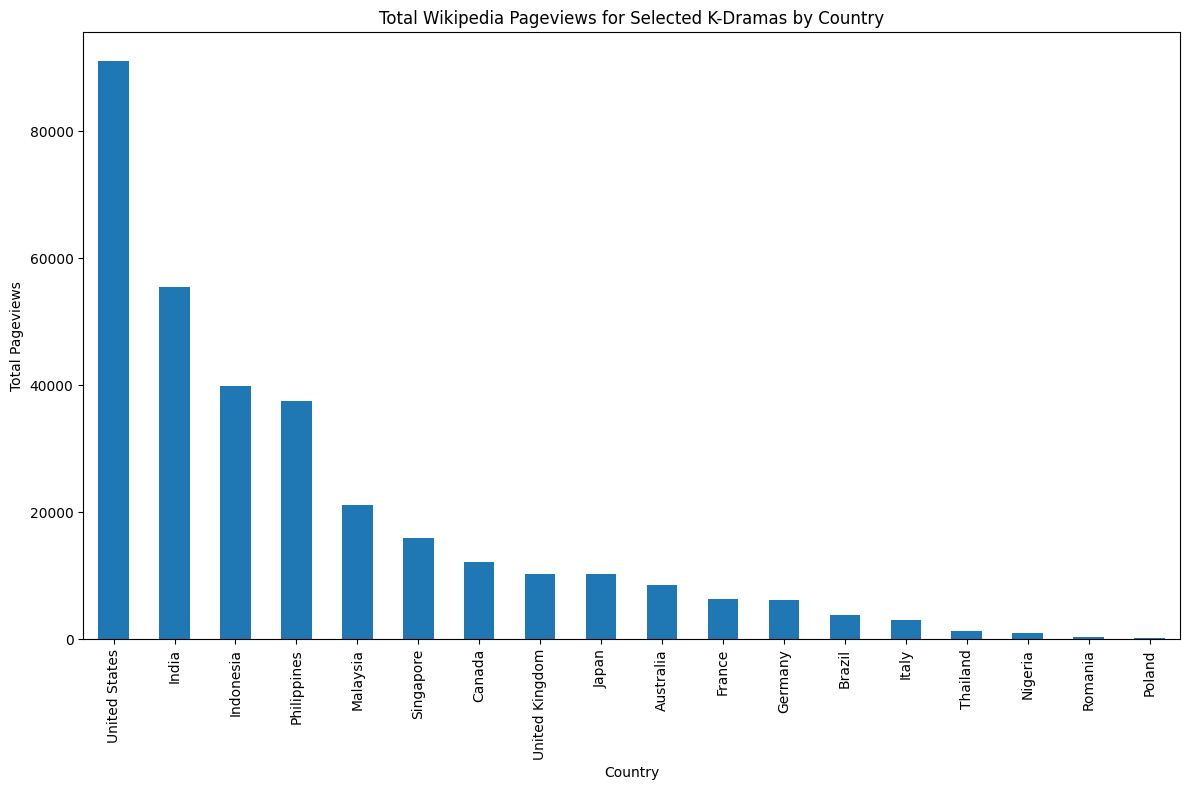

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

country_totals.plot(kind="bar")

plt.title("Total Wikipedia Pageviews for Selected K-Dramas by Country")
plt.xlabel("Country")
plt.ylabel("Total Pageviews")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Bar Chart 2

In [50]:
show_totals = (
    september_df
    .groupby("page_title")["gbc"]
    .sum()
    .sort_values(ascending=False)
)

show_totals

page_title
Four_Hands,_Two_Sonatas          105309
A_Bona_Fide_Killer                70404
Agent_Kim_Reactivated             54615
Teach_You_a_Lesson                47148
A_Shop_for_Killers                18133
The_Wonderfools                   13836
Bloodhounds_(TV_series)            8183
The_Legend_of_Kitchen_Soldier      3870
We_Are_All_Trying_Here             2492
In_Your_Radiant_Season              778
Name: gbc, dtype: int64

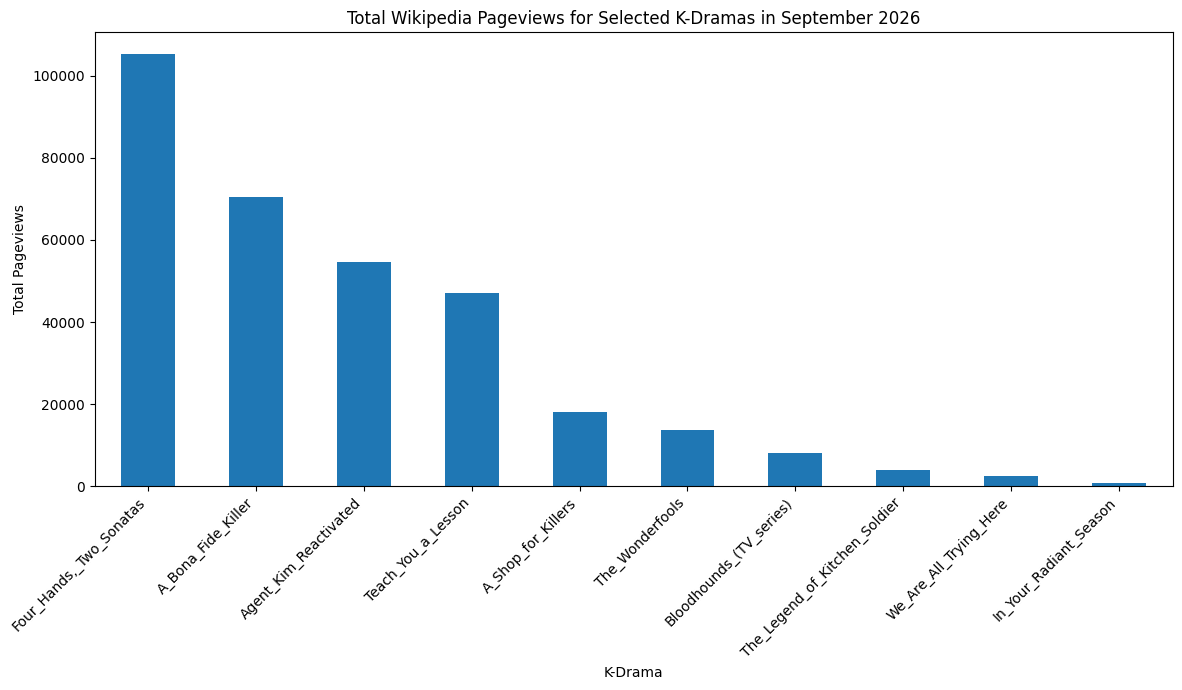

In [51]:
plt.figure(figsize=(12, 7))

show_totals.plot(kind="bar")

plt.title("Total Wikipedia Pageviews for Selected K-Dramas in September 2026")
plt.xlabel("K-Drama")
plt.ylabel("Total Pageviews")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Understanding

In [52]:
show_results = show_totals.reset_index()

show_results.columns = [
    "wikipedia_title",
    "total_pageviews"
]

show_results

,wikipedia_title,total_pageviews
0,"Four_Hands,_Two_Sonatas",105309
1,A_Bona_Fide_Killer,70404
2,Agent_Kim_Reactivated,54615
3,Teach_You_a_Lesson,47148
4,A_Shop_for_Killers,18133
5,The_Wonderfools,13836
6,Bloodhounds_(TV_series),8183
7,The_Legend_of_Kitchen_Soldier,3870
8,We_Are_All_Trying_Here,2492
9,In_Your_Radiant_Season,778


In [53]:
comparison = shows.merge(
    show_results,
    on="wikipedia_title",
    how="left"
)

In [54]:
comparison.sort_values(
    "total_pageviews",
    ascending=False
)

,mdl_title,wikipedia_title,mdl_rating,total_pageviews
1,"Four Hands, Two Sonatas","Four_Hands,_Two_Sonatas",8.7,105309
9,A Bona Fide Killer,A_Bona_Fide_Killer,8.4,70404
3,Agent Kim Reactivated,Agent_Kim_Reactivated,8.6,54615
0,Teach You a Lesson,Teach_You_a_Lesson,9.0,47148
5,A Shop for Killers Season 2,A_Shop_for_Killers,8.5,18133
6,The WONDERfools,The_Wonderfools,8.5,13836
2,Bloodhounds Season 2,Bloodhounds_(TV_series),8.7,8183
7,The Legend of Kitchen Soldier,The_Legend_of_Kitchen_Soldier,8.5,3870
4,We Are All Trying Here,We_Are_All_Trying_Here,8.5,2492
8,In Your Radiant Season,In_Your_Radiant_Season,8.4,778


It looks like A Bona Fide Killer is really popular on Wikipedia, even though it's rated lower on MDL! That's very interesting.